In [11]:
from pathlib import Path
from ultralytics import YOLO
from ultralytics.utils.plotting import colorize_depth
import matplotlib.pyplot as plt
import numpy as np
import cv2
import pandas as pd
from itertools import islice

DEPTH_DATA_ROOT = Path("/mnt/NVME_DATA/kpetrakis/depth_data")
dataset = "22b7a606-acc3-4c51-b1b0-8669c2b85e8a"
DATA = DEPTH_DATA_ROOT / dataset
IMAGES = DATA / "images"
LABELS = DATA / "labels"

DEPTH_NPY_DIR = Path.cwd() / "depth_npy"
VIZ_DIR = Path.cwd() / "visualizations"
(VIZ_DIR / "colored").mkdir(parents=True, exist_ok=True)
(VIZ_DIR / "metric").mkdir(parents=True, exist_ok=True)
(VIZ_DIR / "overlay").mkdir(parents=True, exist_ok=True)
(VIZ_DIR / "histograms").mkdir(parents=True, exist_ok=True)

COLORED_DIR = VIZ_DIR / "colored"
METRIC_DIR = VIZ_DIR / "metric"
OVERLAY_DIR = VIZ_DIR / "overlay"

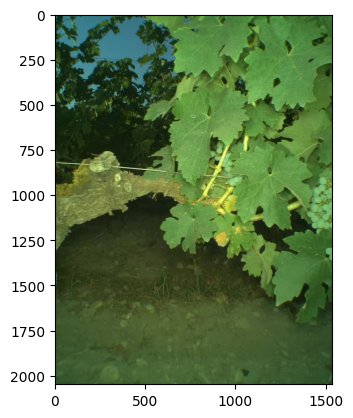


image 1/1 /mnt/NVME_DATA/kpetrakis/depth_data/22b7a606-acc3-4c51-b1b0-8669c2b85e8a/images/5b178450-176b-4c24-b6a4-7173d1e752e9_R_00000236.png: 768x576 depth 0.91-7.52m, 3.8ms
Speed: 1.8ms preprocess, 3.8ms inference, 0.1ms postprocess per image at shape (1, 3, 768, 576)


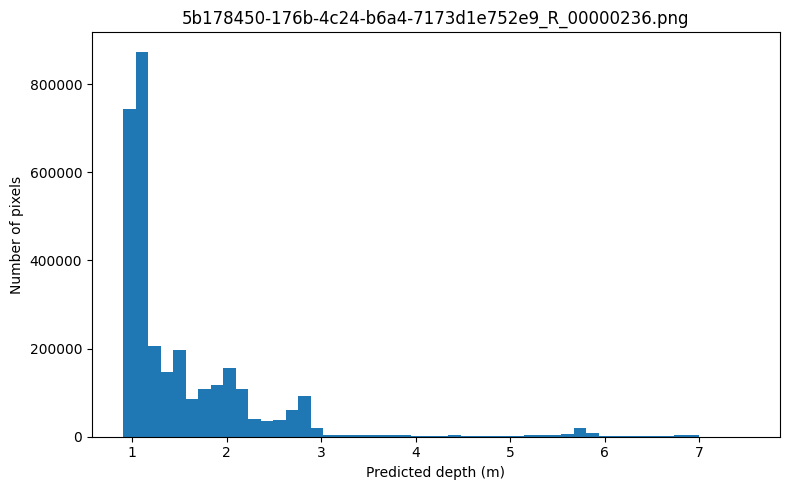

In [7]:
# img_path = DATA / "images/f5fa3a11-5194-43e5-8cdc-e216a74226bc_R_00000425.png" # 1783334468_p0000_R_frame_0025653.jpg"
# img_path = DATA / "images/3ca4bebf-cb9a-4f5d-be0c-7520efbb4bd5_R_00000436.png" # GOOD EXAMPLE of depthh working
img_path = DATA / "images/5b178450-176b-4c24-b6a4-7173d1e752e9_R_00000236.png"

img_stem = img_path.stem
img_suffix = img_path.suffix

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

model = YOLO("yolo26n-depth.pt")
result = model(img_path, imgsz=768)[0]
depth_map = result.depth.data.cpu().numpy() # (H, W) float32, meters
depth_path = DEPTH_NPY_DIR / f"{img_path.stem}.npy"
np.save(depth_path, depth_map)

# Colorize with near = warm and save. NOTE: The same color does not represent the same physical distance between different images. (automatic scale)
cv2.imwrite(f"{COLORED_DIR}/{img_path.stem}{img_suffix}", colorize_depth(depth_map, cmap="spectral"))  # (H, W, 3) BGR uint8

# Fix the range to 0-20 m so the same color means the same distance across frames. (fixed scale)
cv2.imwrite(f"{METRIC_DIR}/{img_path.stem}{img_suffix}", colorize_depth(depth_map, vmin=0.0, vmax=20.0, cmap="inferno", mode="metric"))

# Blended overlay straight from the Results object (uses cmap="jet", mode="disparity")
result.save(f"{OVERLAY_DIR}/{img_path.stem}{img_suffix}")

finite = np.isfinite(depth_map)
valid_depth = depth_map[finite]

row = {
  "image": img_path.name,
  "depth_npy": f"{img_path.stem}.npy",
  "model": "yolo26n-depth",
  "imgsz": 768,
  "height": depth_map.shape[0],
  "width": depth_map.shape[1],
  "dtype": str(depth_map.dtype),

  "min_m": float(np.min(valid_depth)),
  "max_m": float(np.max(valid_depth)),
  "mean_m": float(np.mean(valid_depth)),
  "median_m": float(np.median(valid_depth)),

  "q01_m": float(np.percentile(valid_depth, 1)),
  "q05_m": float(np.percentile(valid_depth, 5)),
  "q25_m": float(np.percentile(valid_depth, 25)),
  "q75_m": float(np.percentile(valid_depth, 75)),
  "q95_m": float(np.percentile(valid_depth, 95)),
  "q99_m": float(np.percentile(valid_depth, 99)),

  "num_pixels": int(depth_map.size),
  "num_valid": int(np.sum(finite)),
  "num_invalid": int(np.sum(~finite)),
}

df = pd.DataFrame([row])
# df.to_csv(VIZ_DIR / "depth_stats.csv", index=False)

# Create histogramm for image
plt.figure(figsize=(8, 5))
# plt.hist(depth_map, bins=100)
plt.hist(valid_depth, bins=50)

plt.xlabel("Predicted depth (m)")
plt.ylabel("Number of pixels")
plt.title(img_path.name)
# plt.yscale('log')
plt.tight_layout()

In [16]:
# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------
IMAGE_DIR = DATA / "images"
STATS_CSV = VIZ_DIR / "depth_stats.csv"

# ---------------------------------------------------------
# params
# ---------------------------------------------------------
IMAGE_SIZE = 768
yolo_variant = "yolo26n-depth.pt"

# ---------------------------------------------------------
# Model
# ---------------------------------------------------------
model = YOLO(yolo_variant)

# ---------------------------------------------------------
# Images
# ---------------------------------------------------------
image_paths = sorted(
  p for p in IMAGE_DIR.iterdir()
  if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

print(f"Found {len(image_paths)} images")

# ---------------------------------------------------------
# Run inference
# ---------------------------------------------------------
rows = []
# for i, img_path in islice(enumerate(image_paths), 3):
for i, img_path in enumerate(image_paths):
  # print(f"[{i + 1}/{len(image_paths)}] {img_path.name}")

  result = model(img_path, imgsz=IMAGE_SIZE, verbose=False)[0]
  depth_map = result.depth.data.cpu().numpy().astype(np.float32) # (H, W) float32, meters
  depth_path = DEPTH_NPY_DIR / f"{img_path.stem}.npy"
  np.save(depth_path, depth_map)

  # Valid values
  finite = np.isfinite(depth_map)
  valid_depth = depth_map[finite]
  if len(valid_depth) == 0:
    print("WARNING: no valid depth values")
    continue

  # -----------------------------------------------------
  # Per-image statistics
  # -----------------------------------------------------
  row = {
    "image": img_path.name,
    "depth_npy": depth_path.name,
    "model": yolo_variant,
    "imgsz": IMAGE_SIZE,
    "height": depth_map.shape[0],
    "width": depth_map.shape[1],
    "dtype": str(depth_map.dtype),

    "min_m": float(np.min(valid_depth)),
    "max_m": float(np.max(valid_depth)),
    "mean_m": float(np.mean(valid_depth)),
    "median_m": float(np.median(valid_depth)),

    "q01_m": float(np.percentile(valid_depth, 1)),
    "q05_m": float(np.percentile(valid_depth, 5)),
    "q25_m": float(np.percentile(valid_depth, 25)),
    "q75_m": float(np.percentile(valid_depth, 75)),
    "q95_m": float(np.percentile(valid_depth, 95)),
    "q99_m": float(np.percentile(valid_depth, 99)),

    "num_pixels": int(depth_map.size),
    "num_valid": int(np.sum(finite)),
    "num_invalid": int(np.sum(~finite)),
    "valid_fraction": float(np.mean(finite)),
  }

  rows.append(row)

# ---------------------------------------------------------
# Save CSV
# ---------------------------------------------------------
df = pd.DataFrame(rows)
df.to_csv(STATS_CSV, index=False)
print(f"\nSaved statistics to: {STATS_CSV}")
df.head()

Found 1800 images

Saved statistics to: /home/kpetrakis/ml-sandbox/notebooks/depth/visualizations/depth_stats.csv


,image,depth_npy,model,imgsz,height,width,dtype,min_m,max_m,mean_m,...,q01_m,q05_m,q25_m,q75_m,q95_m,q99_m,num_pixels,num_valid,num_invalid,valid_fraction
0,1753417522_p0300_L_frame_0000001.jpg,1753417522_p0300_L_frame_0000001.npy,yolo26n-depth.pt,768,2048,1536,float32,2.277725,28.304617,12.890647,...,2.371262,2.563485,3.842874,27.030670,28.099682,28.208979,3145728,3145728,0,1.0
1,1753417522_p0300_L_frame_0005141.jpg,1753417522_p0300_L_frame_0005141.npy,yolo26n-depth.pt,768,2048,1536,float32,0.590776,1.044988,0.697496,...,0.595289,0.605817,0.627387,0.714257,0.966833,1.032488,3145728,3145728,0,1.0
2,1753417522_p0300_L_frame_0006546.jpg,1753417522_p0300_L_frame_0006546.npy,yolo26n-depth.pt,768,2048,1536,float32,0.868967,2.905233,1.461825,...,0.918253,0.953390,1.044049,1.789013,2.591619,2.752312,3145728,3145728,0,1.0
3,1753417522_p0300_L_frame_0007856.jpg,1753417522_p0300_L_frame_0007856.npy,yolo26n-depth.pt,768,2048,1536,float32,0.745228,1.835499,1.193299,...,0.782943,0.811418,0.975672,1.377883,1.678038,1.753653,3145728,3145728,0,1.0
4,1753417522_p0300_L_frame_0012358.jpg,1753417522_p0300_L_frame_0012358.npy,yolo26n-depth.pt,768,2048,1536,float32,0.812283,2.852596,1.068840,...,0.827044,0.868188,0.922221,1.136773,1.612770,1.673541,3145728,3145728,0,1.0


In [8]:
from itertools import islice

image_paths_with_annotations = []
# for img_path, label_path in islice(zip(sorted(IMAGES.iterdir()), sorted(LABELS.iterdir())), 5):
for img_path, label_path in zip(sorted(IMAGES.iterdir()), sorted(LABELS.iterdir())):
  assert img_path.stem == label_path.stem, "ERROR"
  # print(img_path, label_path)
  with label_path.open(encoding = 'utf-8') as f:
    if len(f.readlines()) > 0:
      image_paths_with_annotations.append(img_path)
    # for line in f:
      # print(f"{label_path.stem} : {line}")
      # parts = line.strip().split()

In [9]:
len(sorted(IMAGES.iterdir()))

1800

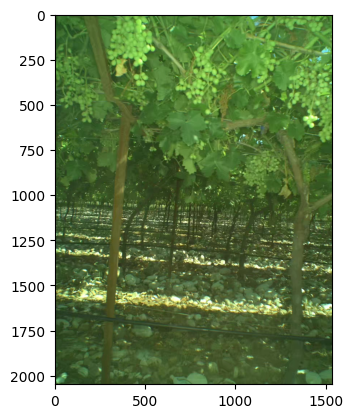


image 1/1 /mnt/NVME_DATA/kpetrakis/depth_data/22b7a606-acc3-4c51-b1b0-8669c2b85e8a/images/1782111430_p0000_R_frame_0014083.jpg: 768x576 depth 0.97-3.45m, 4.1ms
Speed: 1.6ms preprocess, 4.1ms inference, 0.1ms postprocess per image at shape (1, 3, 768, 576)
depth_map min = 0.9732056856155396, max = 3.448420286178589


'depth_overlay.png'

In [10]:
inference_img_path = image_paths_with_annotations[210] # 2*, 71, 200*, 210

img = cv2.imread(inference_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

model = YOLO("yolo26n-depth.pt")
result = model(inference_img_path, imgsz=768)[0]
depth_map = result.depth.data.cpu().numpy() # (H, W) float32, meters
print(f"depth_map min = {depth_map.min()}, max = {depth_map.max()}")

# Colorize with near = warm and save
cv2.imwrite("depth_colored.png", colorize_depth(depth_map, cmap="spectral"))  # (H, W, 3) BGR uint8

# Fix the range to 0-20 m so the same color means the same distance across frames
cv2.imwrite("depth_metric.png", colorize_depth(depth_map, vmin=0.0, vmax=20.0, cmap="inferno", mode="metric"))

# Blended overlay straight from the Results object (uses cmap="jet", mode="disparity")
result.save("depth_overlay.png")